In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_maximum_distances)=
# Get maximum distances

*Calculating maximum spatial distances between atom selections or molecular groups.*

The function {func}`molsysmt.structure.get_maximum_distances` calculates the maximum distance (such as molecular diameter or span) and identifies the furthest atom pair between selections across single or multiple trajectory structures.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.get_maximum_distances`.
:::


## Basic usage

Let's show how to calculate the maximum spatial span (diameter) of a peptide over a trajectory:


In [2]:
import molsysmt as msm
import matplotlib.pyplot as plt
import pyunitwizard as puw


In [3]:
molsys = msm.convert(msm.systems['pentalanine']['traj_pentalanine.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We calculate the maximum distance across all atoms in the system using {func}`molsysmt.structure.get_maximum_distances`:


In [4]:
pairs, max_distances = msm.structure.get_maximum_distances(molsys)


In [5]:
print('Pairs array shape:', pairs.shape)
print('Maximum distances shape:', max_distances.shape)
print(f'System diameter at frame 0: {max_distances[0]:.3f} (between atom {pairs[0,0]} and {pairs[0,1]})')


Pairs array shape: (5000, 2)
Maximum distances shape: (5000,)
System diameter at frame 0: 1.610 nanometer (between atom 3 and 61)


## Plotting maximum span time series

We plot the maximum system span over trajectory time to monitor conformational extension:


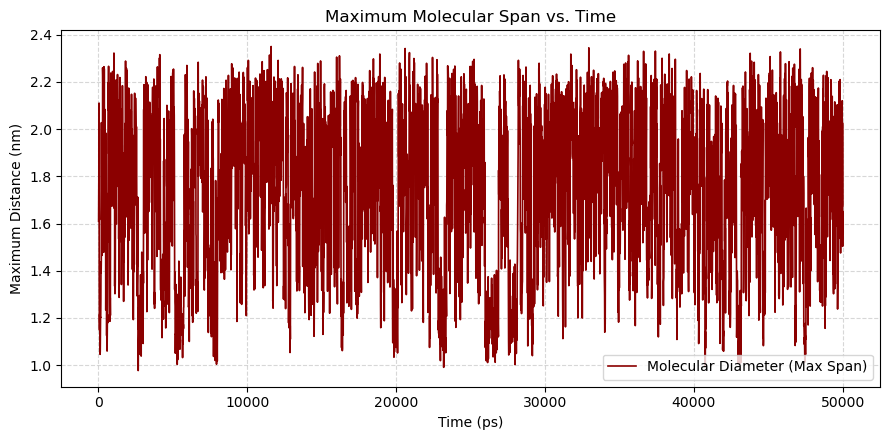

In [6]:
time = msm.get(molsys, element='system', time=True)
time_val = puw.get_value(time, to_unit='ps')
dist_val = puw.get_value(max_distances, to_unit='nm')

plt.figure(figsize=(9, 4.5))
plt.plot(time_val, dist_val, color='darkred', lw=1.2, label='Molecular Diameter (Max Span)')
plt.xlabel('Time (ps)')
plt.ylabel('Maximum Distance (nm)')
plt.title('Maximum Molecular Span vs. Time')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## Computing maximum distances between atom sets

We can find the maximum separation between two separate groups of atoms (e.g. between terminal residues 0 and 4):


In [7]:
pairs_sets, max_d_sets = msm.structure.get_maximum_distances(molsys, selection='group_index==0', selection_2='group_index==4')
print(f'Max distance between terminal residues at frame 0: {max_d_sets[0]:.3f} (atoms {pairs_sets[0,0]} and {pairs_sets[0,1]})')


Max distance between terminal residues at frame 0: 1.297 nanometer (atoms 3 and 9)


## Computing maximum distances between group centers

Setting `center_of_atoms=True` and `center_of_atoms_2=True` measures the maximum distance between group centroids:


In [8]:
groups = msm.get(molsys, element='group', atom_index=True)
pairs_cent, max_d_cent = msm.structure.get_maximum_distances(molsys, selection=groups[0], selection_2=groups[-1], center_of_atoms=True, center_of_atoms_2=True)
print(f'Max centroid distance at frame 0: {max_d_cent[0]:.3f}')


Max centroid distance at frame 0: 1.430 nanometer


## Measuring maximum displacements across structures

Using `pairs=True` between different structures identifies the atom that underwent the largest displacement between consecutive time frames:


In [9]:
pairs_disp, max_disp = msm.structure.get_maximum_distances(molsys, structure_indices=[0, 1], structure_indices_2=[1, 2], pairs=True)
print(f'Atom {pairs_disp[0]} had the maximum displacement ({max_disp[0]:.4f}) between frames 0 and 1.')
print(f'Atom {pairs_disp[1]} had the maximum displacement ({max_disp[1]:.4f}) between frames 1 and 2.')


Atom 22 had the maximum displacement (1.0493 nanometer) between frames 0 and 1.
Atom 0 had the maximum displacement (1.3950 nanometer) between frames 1 and 2.


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Get <Tutorial_Get>`: Query system time and structural attributes with {func}`molsysmt.basic.get`.
- {ref}`Get distances <Tutorial_Get_distances>`: Compute full pairwise distance matrices with {func}`molsysmt.structure.get_distances`.
- {ref}`Get minimum distances <Tutorial_Get_minimum_distances>`: Find the closest separation between elements with {func}`molsysmt.structure.get_minimum_distances`.
- {ref}`Get radius of gyration <Tutorial_Get_radius_of_gyration>`: Measure spatial compactness with {func}`molsysmt.structure.get_radius_of_gyration`.
:::
